**Kịch bản Thực nghiệm Tái lập Bản đồ Logistic: So sánh Đối ngẫu Động lực học (Marwan, 2002)**

Mục tiêu của thiết kế thực nghiệm này là tái lập chuẩn xác hệ quy chiếu lý thuyết trên bản đồ Logistic, nhằm đánh giá và so sánh khả năng của bộ chỉ số RQA dọc và RQA chéo trong việc phát hiện các chuyển pha hỗn loạn - hỗn loạn (chaos-chaos transitions). 

---

### 1. Cấu hình Toán học & Thiết lập Dữ liệu (Mathematical Setup)

*   **Hệ động lực nền tảng:** Phương trình sai phân Logistic Map $x_{n+1} = a x_n (1 - x_n)$.
*   **Không gian tham số ($a$):** Quét dải $a \in [3.5, 4.0]$ với $\Delta a = 0.0005$ (1001 điểm lấy mẫu).
*   **Tiền xử lý:** Sinh 2000 điểm mỗi mốc $a$. Loại bỏ 1000 điểm đầu (transient rejection) để triệt tiêu đáp ứng quá độ, giữ 1000 điểm cuối thuộc quỹ đạo ổn định (attractor) để phân tích.
*   **Điều kiện khởi đầu (Anti-trap Initial Condition):** Bài báo không chỉ rõ $x_0$. Nếu dùng $x_0 = 0.5$ (điểm cực trị), tại mốc hỗn loạn $a = 4.0$, hệ sẽ kẹt vào bẫy toán học ($1.0 \rightarrow 0.0 \rightarrow 0.0$). Thực nghiệm chủ động chọn $x_0 = 0.45$ để bảo toàn sự phát triển quỹ đạo.

### 2. Chiến lược Nhúng Không gian pha (Embedding Strategy)

Áp dụng cấu hình nhúng kép để phục vụ đúng mục đích toán học và trực quan:

*   **Hình 1 & 3 (Lượng hóa):** $m = 1, \tau = 1, \epsilon = 0.1 \times Diameter$. Vì bản chất hệ là một chiều, giữ $m=1$ đảm bảo không làm méo lệch các phân bố hình học $P(l)$ và $P(v)$.
*   **Hình 2 (Trực quan RP):** $m = 3, \tau = 1$. Việc tăng chiều nhúng hoạt động như một bộ lọc không gian (spatial filter), giúp phân tách các điểm hồi quy và khuếch đại cấu trúc khối chữ nhật để mắt thường dễ quan sát.

### 3. Tối ưu hóa Thuật toán (Algorithmic Optimization)

*   Sử dụng Numba JIT (Just-In-Time) để biên dịch thuật toán quét dòng sang mã máy (C-speed).
*   **Benchmark:** Toàn bộ chu trình khởi tạo, dựng 1001 ma trận ($1000 \times 1000$), quét định lượng và kết xuất đồ thị hoàn thành trong **15.59 giây**. Hiệu năng này cho thấy thuật toán đủ nhanh để xử lý các thực nghiệm quy mô lớn và tạo tiền đề cho tiềm năng triển khai gần thời gian thực (near real-time) trên dữ liệu y sinh (PPG) trong nghiên cứu tiếp theo.

---

### 4. Phân tích So khớp (Theory $\rightarrow$ Geometry $\rightarrow$ Measurement)

#### Hình 1: Lý thuyết (Theory)
*   Hiển thị Bifurcation Diagram và 10 hàm Supertracks đầu tiên. 
*   Giao điểm giữa siêu quỹ đạo và điểm cố định không ổn định ($1 - 1/a$) định vị chính xác 6 mốc chuyển pha chaos-chaos lý thuyết.

#### Hình 2: Hình học (Geometry)
Tái lập hình thái phân lập của 4 trạng thái định tính:
*   **Tuần hoàn ($a = 3.830$):** Chỉ chứa các đường chéo mảnh song song.
*   **Gộp băng ($a = 3.679$):** Xuất hiện các khối chữ nhật đen khổng lồ (minh chứng của laminar phases lưu trú dài hạn).
*   **Giao cắt siêu quỹ đạo ($a = 3.720$):** Chứa các chữ thập đen nhỏ (laminar ngắn hạn).
*   **Hỗn loạn toàn phần ($a = 4.000$):** Ma trận đồng nhất với các điểm phân tán.

#### Hình 3: Lượng hóa (**Evolution** vs. **Persistence**)
*   **Khả năng của RQA Chéo (**Evolution**):** Các chỉ số (DET, $L_{max}$, $L_{mean}$) đạt đỉnh tại cửa sổ tuần hoàn nhưng hoàn toàn phẳng lặng tại tọa độ của 6 mốc chuyển pha chaos-chaos.
*   **Khả năng của RQA Dọc (**Persistence**):** Các chỉ số (LAM, $V_{max}$, TT) triệt tiêu tại pha tuần hoàn, nhưng đồng loạt xuất hiện các cực đại cục bộ (local maxima) trùng khớp tuyệt đối với 6 mốc chuyển pha lý thuyết. 
*   **Xác nhận cơ chế vật lý:** Tại vùng $a < 3.678$, quỹ đạo nhảy băng hỗn loạn liên tục, không thể lưu trú. Kết quả trả về Trapping Time và $V_{max}$ bằng 0 tuyệt đối và chỉ bắt đầu tăng sau mốc gộp băng.

# CELL 1: Khai báo thư viện (Environment & Configurations)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import sys
import os

# Nạp module RQA từ thư mục lõi
sys.path.append(os.path.abspath(".."))
from core_ntsa.rqa2002 import run_webber2002, run_marwan2002

# =============================================================================
# Cấu hình đồ họa chất lượng xuất bản (Publication-quality parameters)
# =============================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],  # Chuẩn bài báo học thuật
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.linewidth": 1.2,          # Độ dày viền trục tọa độ
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,              # Độ phân giải hiển thị trên notebook
    "savefig.dpi": 300,             # Độ phân giải khi lưu file ảnh
    "savefig.bbox": "tight",        # Tự động căn chỉnh lề, chống cắt chữ
    "figure.figsize": (10, 6),      # Kích thước khung hình mặc định
    "axes.grid": False              # Tắt grid mặc định để đồ thị sắc nét hơn
})


# CELL 2: Trình tạo Dữ liệu Hệ Động lực (Logistic Map Generator)


In [2]:
def generate_logistic_map(a: float, x0: float = 0.45, n_total: int = 2000, n_drop: int = 1000) -> np.ndarray:
    """
    Sinh chuỗi thời gian từ phương trình Logistic Map: x_{n+1} = a * x_n * (1 - x_n).
    
    Reproducibility note (Historical modification):
    Thay vì sử dụng x0 = 0.5 (không được nêu rõ trong bài báo gốc), hàm này sử dụng 
    x0 = 0.45. Việc tinh chỉnh này giúp tránh bẫy quỹ đạo suy biến (degenerate orbit) 
    tại a = 4.0 (khi x biến thiên 1.0 -> 0.0 -> 0.0), đảm bảo quỹ đạo phát triển hỗn loạn 
    hoàn hảo và mượt mà trên toàn dải tham số.
    """
    if n_drop >= n_total:
        raise ValueError("n_drop phải nhỏ hơn n_total.")
        
    x = np.zeros(n_total)
    x[0] = x0
    
    # Tính toán toàn bộ quỹ đạo
    for i in range(1, n_total):
        x[i] = a * x[i-1] * (1.0 - x[i-1])
        
    # Loại bỏ đáp ứng quá độ (transient rejection), chỉ trả về quỹ đạo ổn định
    return x[n_drop:]

# CELL 3: Tái lập Hình 1 (Theory - Bifurcation & Supertracks)

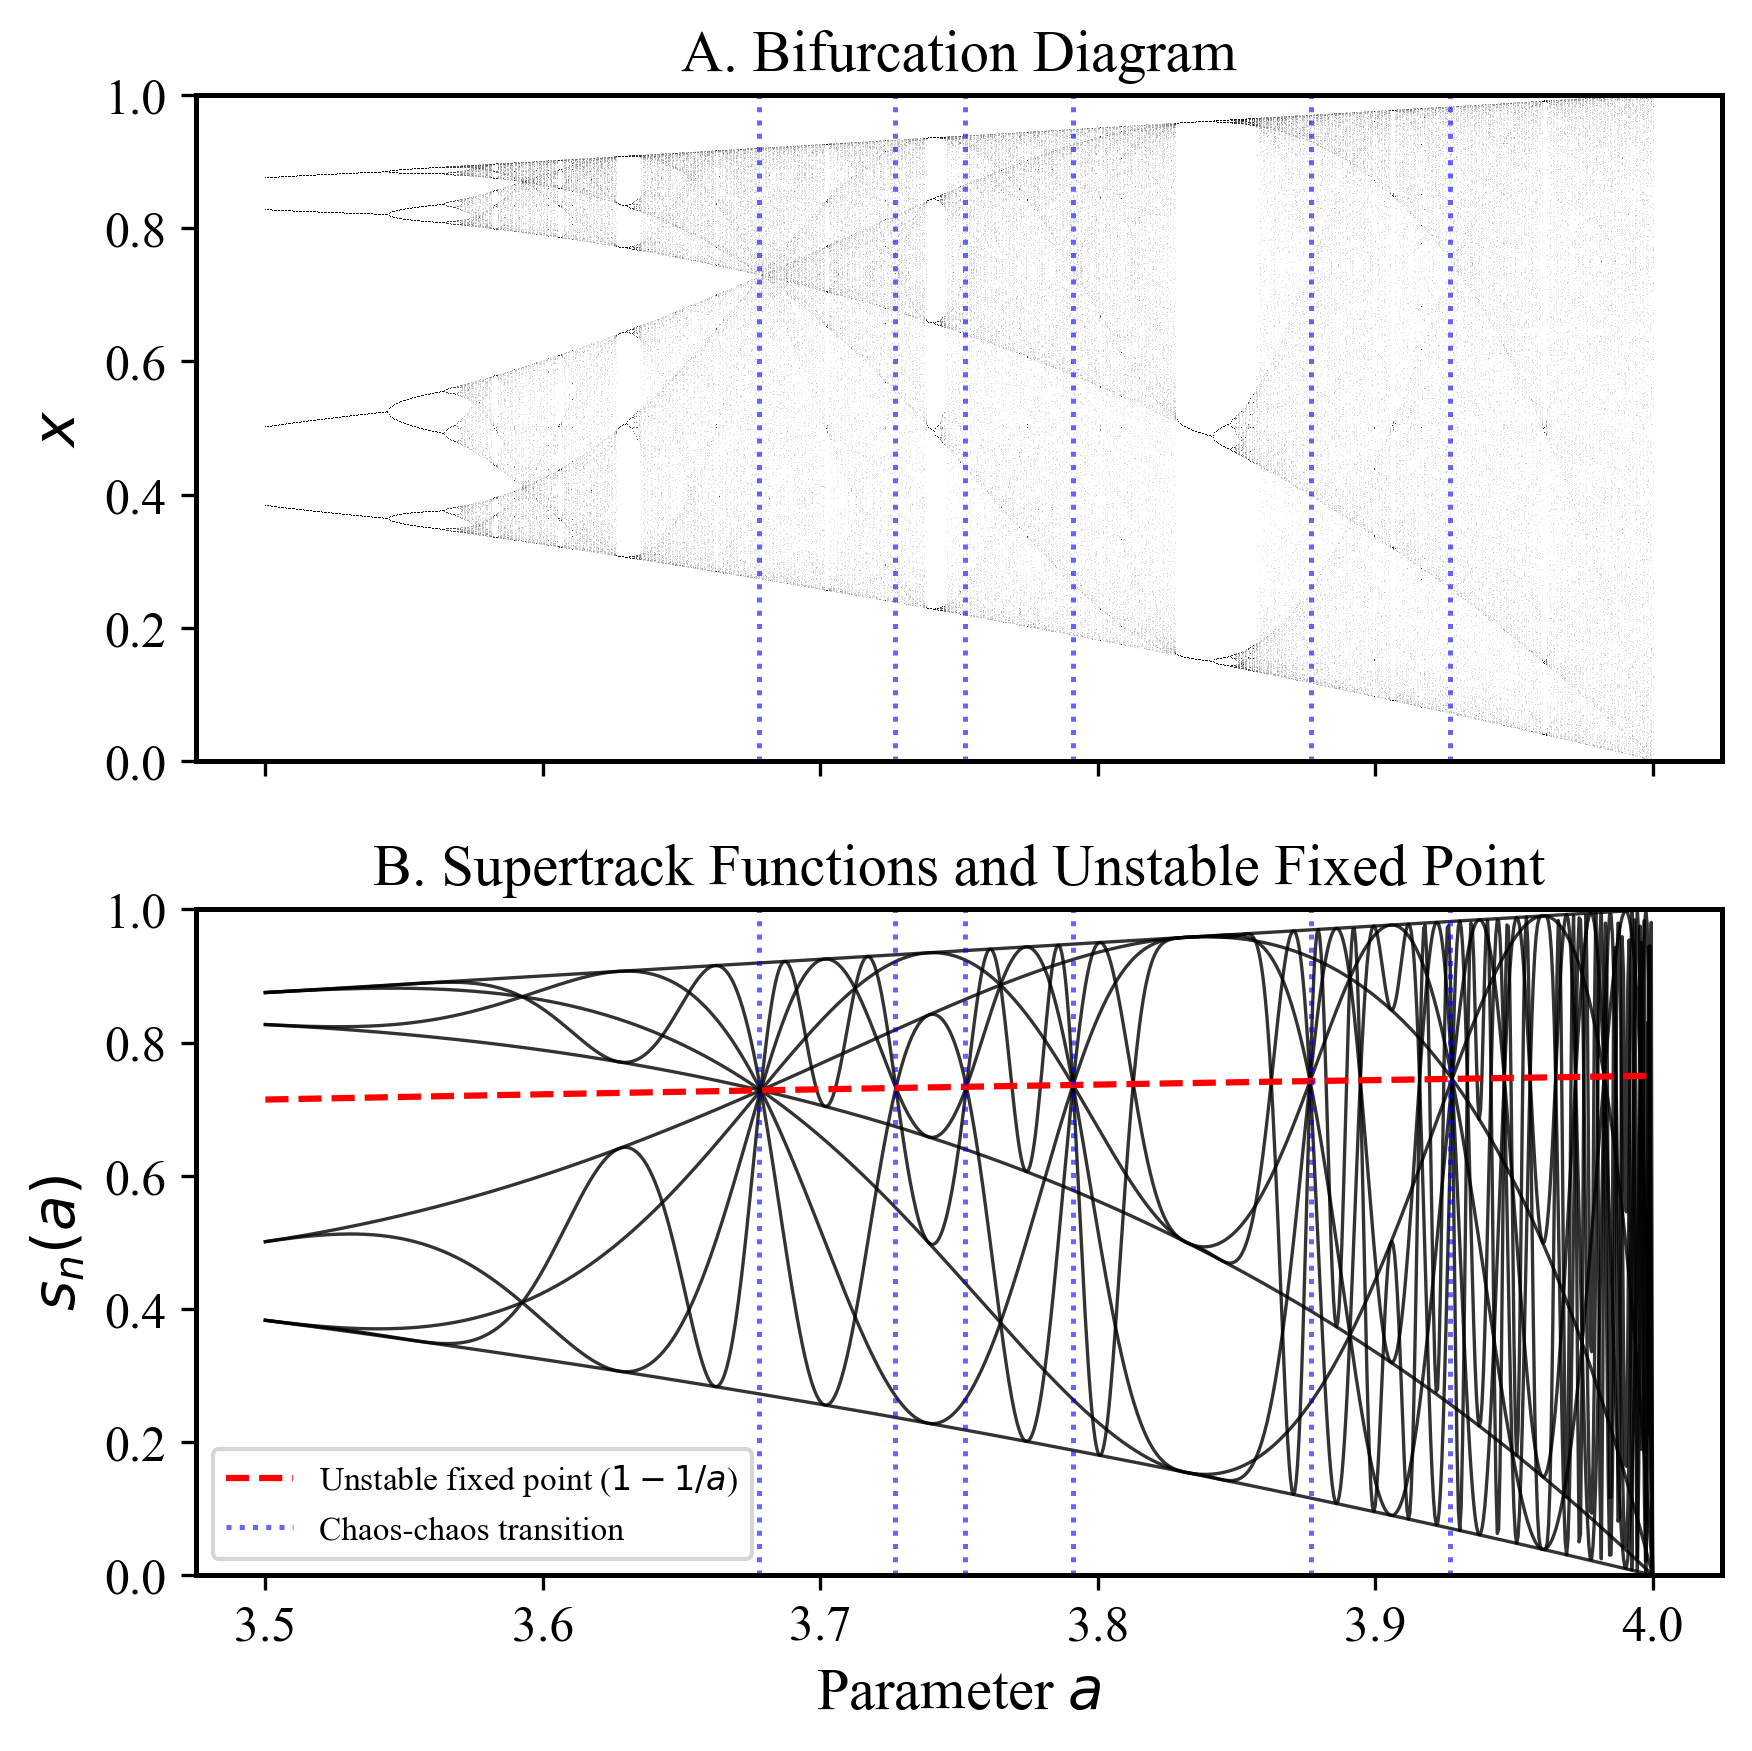

In [6]:
# Khởi tạo không gian tham số
a_values = np.linspace(3.5, 4.0, 1001)

# Known chaos-chaos transition points reported in Marwan (2002)
# Các giá trị lý thuyết này được lưu trữ để làm Ground Truth đối chiếu cho Figure 3.
chaos_transitions = [3.678, 3.727, 3.752, 3.791, 3.877, 3.927] 

# 1. Tính toán dữ liệu Bifurcation
# Lấy 200 điểm cuối cùng của quỹ đạo ổn định tại mỗi giá trị a để vẽ (tránh quá tải)
bifurcation_a = []
bifurcation_x = []
for a in a_values:
    x_stable = generate_logistic_map(a)[-200:]
    bifurcation_a.extend([a] * len(x_stable))
    bifurcation_x.extend(x_stable)

# 2. Tính toán hàm siêu quỹ đạo (Supertracks) và điểm cố định không ổn định
# s_0 = 0.5 (điểm cực trị của Logistic Map)
s_prev = np.full_like(a_values, 0.5)
supertracks = []

for _ in range(10):
    s_curr = a_values * s_prev * (1.0 - s_prev)
    supertracks.append(s_curr)
    s_prev = s_curr

unstable_fixed_point = 1.0 - (1.0 / a_values)

# =============================================================================
# Plotting - Figure 1: Khung xương lý thuyết toán học
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

# Panel A: Bifurcation Diagram
ax1.plot(bifurcation_a, bifurcation_x, ',', color='black', alpha=0.1)
ax1.set_title("A. Bifurcation Diagram")
ax1.set_ylabel(r"$x$")
ax1.set_ylim(0.0, 1.0)

# Panel B: Supertrack Functions
for s_n in supertracks:
    ax2.plot(a_values, s_n, color='black', linewidth=0.8, alpha=0.8)
    
ax2.plot(a_values, unstable_fixed_point, color='red', linestyle='--', 
         linewidth=1.5, label=r"Unstable fixed point ($1 - 1/a$)")

ax2.set_title("B. Supertrack Functions and Unstable Fixed Point")
ax2.set_xlabel(r"Parameter $a$")
ax2.set_ylabel(r"$s_n(a)$")
ax2.set_ylim(0.0, 1.0)

# Kẻ 6 đường đứt nét đánh dấu điểm chuyển pha (Ground Truth)
for idx, t in enumerate(chaos_transitions):
    label = "Chaos-chaos transition" if idx == 0 else None
    ax1.axvline(x=t, color='blue', linestyle=':', linewidth=1.2, alpha=0.6)
    ax2.axvline(x=t, color='blue', linestyle=':', linewidth=1.2, alpha=0.6, label=label)

ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# CELL 4: Tái lập Hình 2 (Geometry - Recurrence Plots)

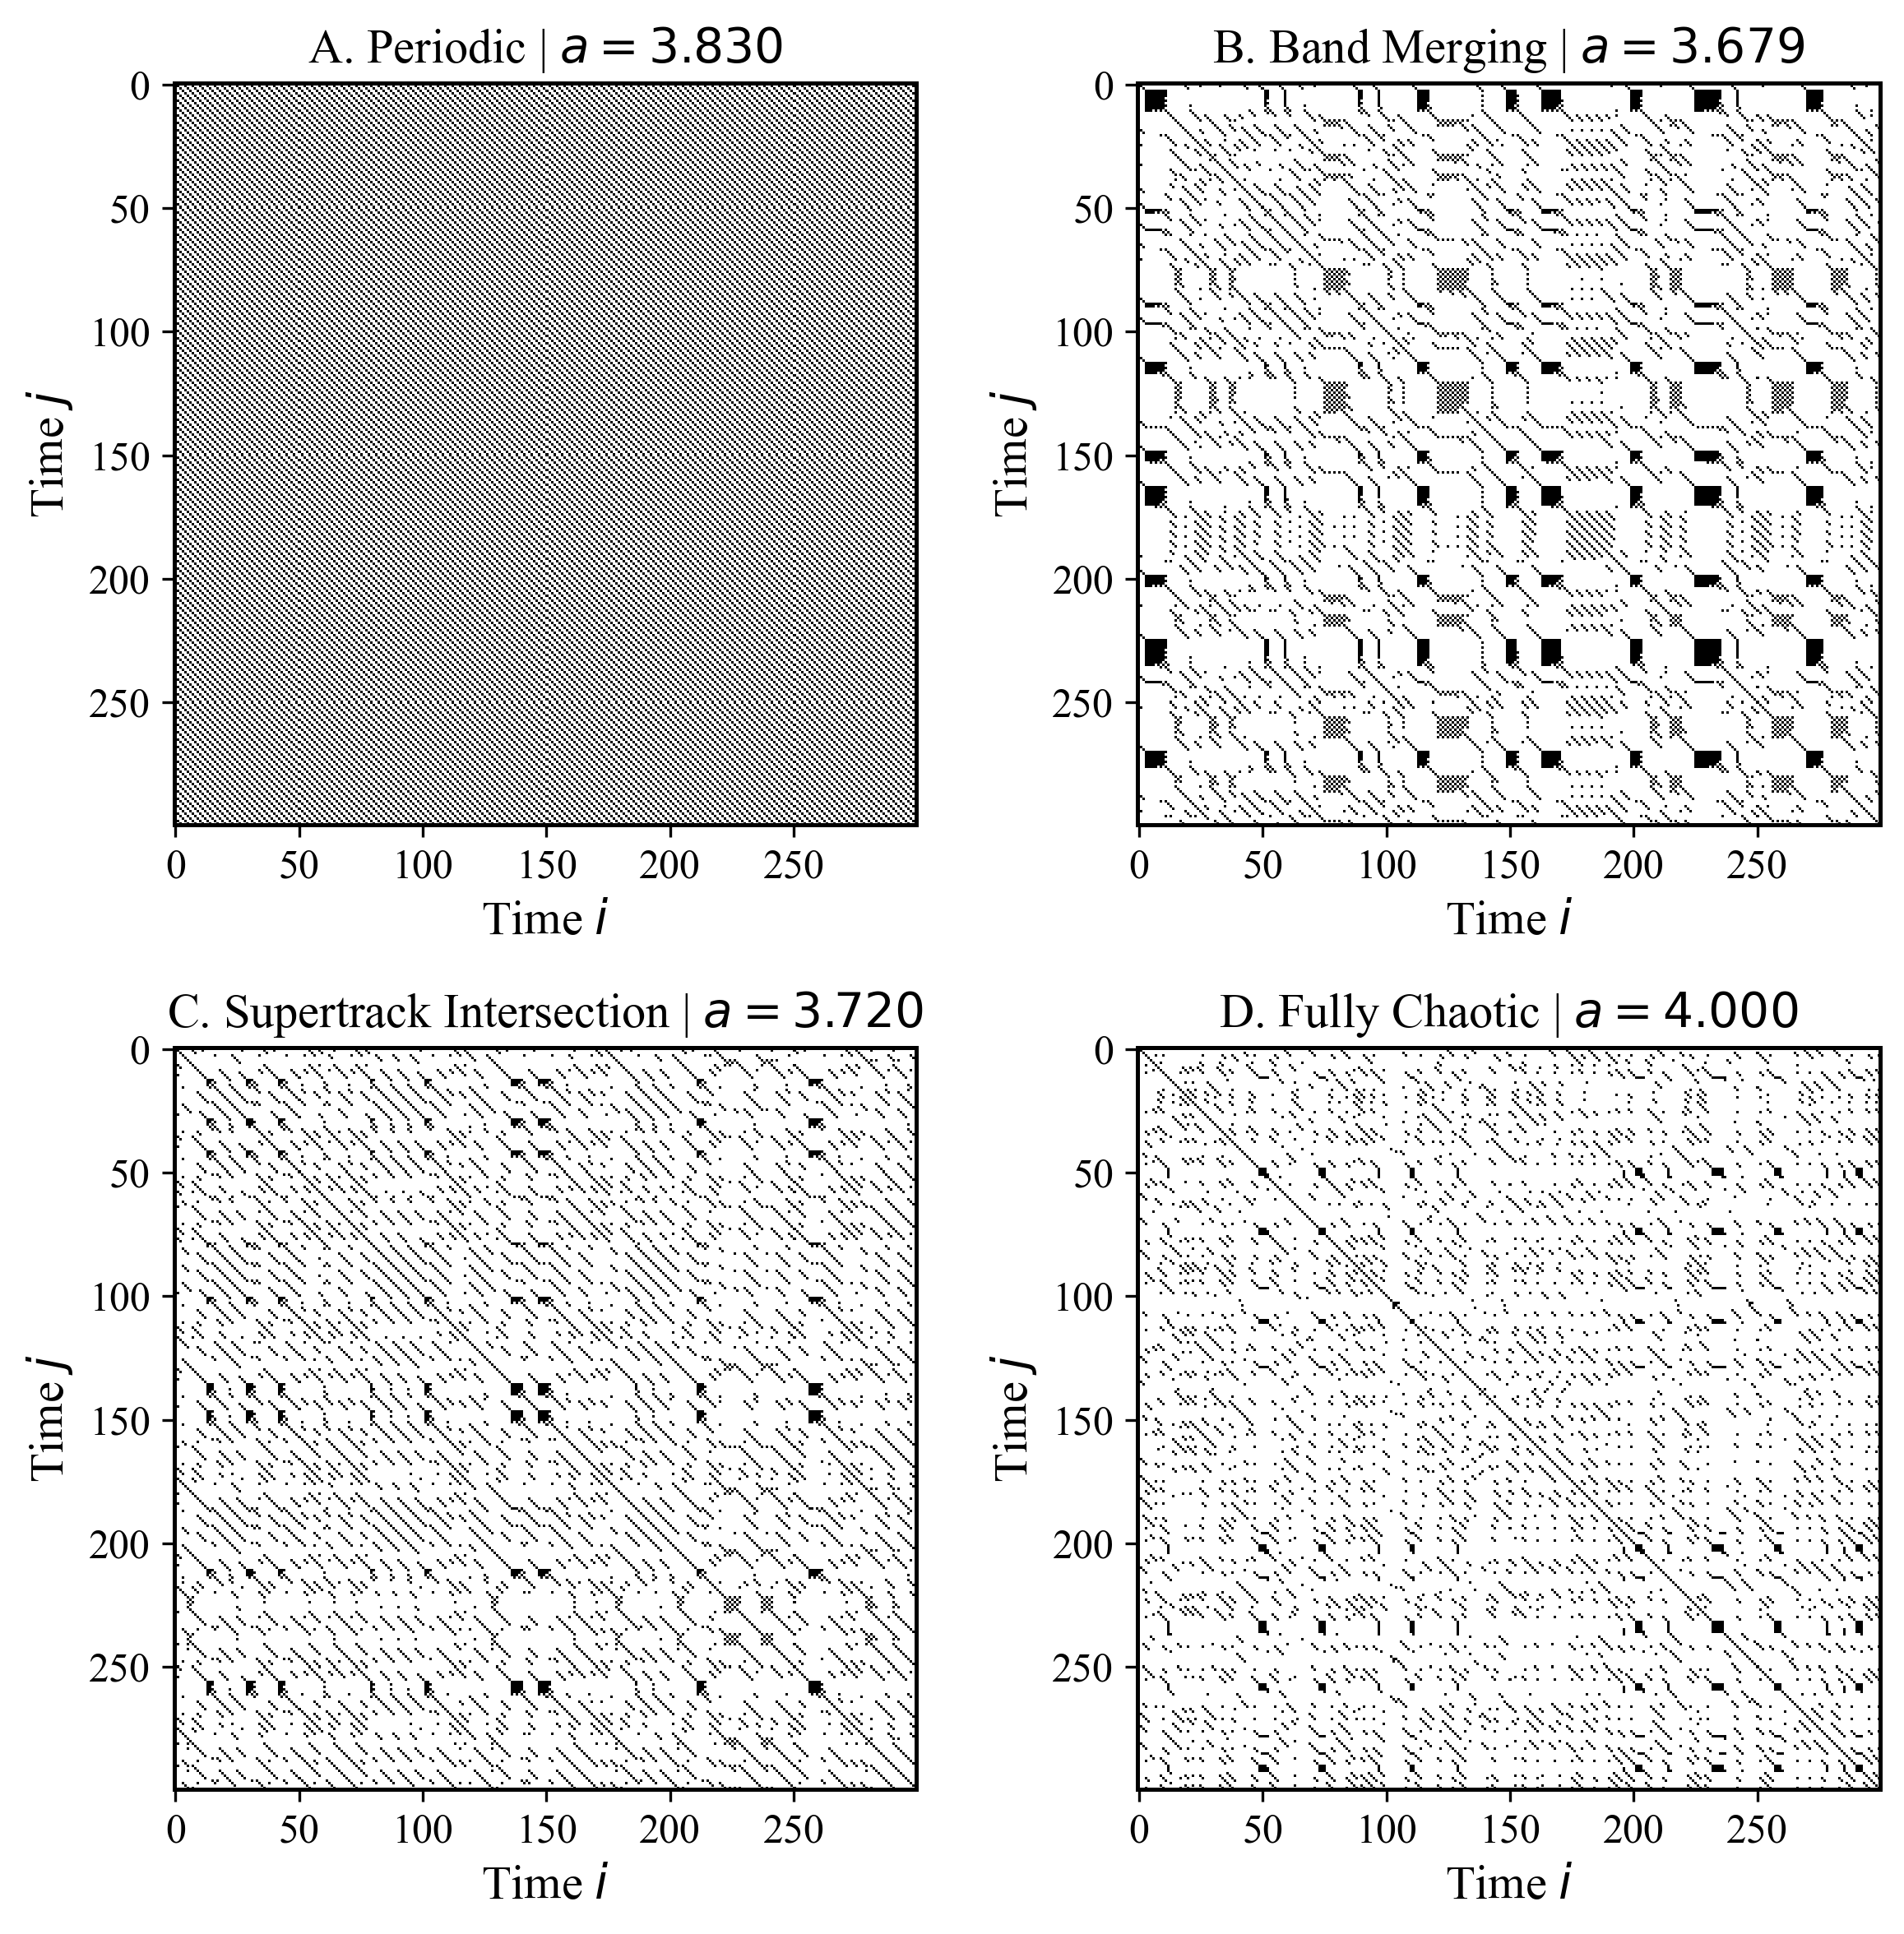

In [8]:
# Import các hàm core độc lập để lấy trực tiếp ma trận R
from core_ntsa.rqa2002 import (
    reconstruct_phase_space, 
    compute_distance_matrix, 
    compute_recurrence_matrix
)

# Khởi tạo 4 trạng thái định tính đặc trưng (chuẩn hóa English titles theo paper)
states = [
    {"a": 3.830, "title": "A. Periodic"},
    {"a": 3.679, "title": "B. Band Merging"},
    {"a": 3.720, "title": "C. Supertrack Intersection"},
    {"a": 4.000, "title": "D. Fully Chaotic"}
]

# Cấu hình nhúng (Spatial Filter cho hiển thị trực quan)
m_geom = 3
tau_geom = 1

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, state in enumerate(states):
    a = state["a"]
    
    # 1. Sinh tín hiệu
    signal = generate_logistic_map(a)
    
    # 2. Nhúng không gian pha 3D
    X = reconstruct_phase_space(signal, m_geom, tau_geom)
    
    # 3. Tính ma trận khoảng cách
    D = compute_distance_matrix(X)
    
    # 4. Tính ngưỡng epsilon (10% đường kính của attractor)
    # Compute the phase-space diameter directly from D to follow the geometric definition.
    epsilon = 0.1 * np.max(D)
    
    # 5. Dựng ma trận RP
    R = compute_recurrence_matrix(D, epsilon)
    
    # 6. Trực quan hóa
    # Plot 300x300 điểm đầu tiên để hiển thị rõ các cấu trúc vi mô hình học
    R_viz = R[:300, :300]
    
    # Sử dụng cmap='binary' và origin='upper' theo chuẩn hiển thị RP, interpolation='none' chống mờ
    axes[i].imshow(R_viz, cmap='binary', origin='upper', interpolation='none')
    axes[i].set_title(f"{state['title']} | $a = {a:.3f}$")
    axes[i].set_xlabel("Time $i$")
    axes[i].set_ylabel("Time $j$")

plt.tight_layout()
plt.show()

# CELL 5: Tái lập Hình 3 (Measurement - Evolution vs. Persistence)

In [10]:
from core_ntsa.rqa2002 import (
    reconstruct_phase_space, 
    compute_distance_matrix, 
    compute_recurrence_matrix,
    _extract_diagonal_lengths, calculate_det, calculate_lmean, calculate_lmax,
    _extract_vertical_lengths, calculate_laminarity, calculate_trapping_time, calculate_vmax
)

# 1. Khởi tạo các vector lưu trữ kết quả (Response curves)
det_curve, lmax_curve, lmean_curve = [], [], []
lam_curve, vmax_curve, tt_curve = [], [], []

# Cấu hình nhúng m=1 để đo lường chính xác hình học 1D của Logistic Map
m_quant = 1
tau_quant = 1

print("Bắt đầu mô phỏng 1001 điểm (có thể mất vài phút)...")

# 2. Vận hành luồng tính toán cốt lõi
for i, a in enumerate(a_values):
    # Trình theo dõi tiến độ
    if i % 100 == 0:
        print(f"Tiến độ: {i}/1001 (a = {a:.3f})")
        
    signal = generate_logistic_map(a)
    X = reconstruct_phase_space(signal, m_quant, tau_quant)
    D = compute_distance_matrix(X)
    
    # Làm rõ định nghĩa hình học: Epsilon = 10% Diameter
    diameter = np.max(D)
    epsilon = 0.1 * diameter
    R = compute_recurrence_matrix(D, epsilon)
    
    # --- RQA CHÉO (EVOLUTION) ---
    diag_lengths = _extract_diagonal_lengths(R)
    det_curve.append(calculate_det(R, diag_lengths))
    lmax_curve.append(calculate_lmax(diag_lengths))
    lmean_curve.append(calculate_lmean(diag_lengths))
    
    # --- RQA DỌC (PERSISTENCE) ---
    vert_lengths = _extract_vertical_lengths(R)
    lam_curve.append(calculate_laminarity(vert_lengths))
    vmax_curve.append(calculate_vmax(vert_lengths))
    tt_curve.append(calculate_trapping_time(vert_lengths))

print("Hoàn thành tính toán! Chuyển sang Cell 6 để kết xuất đồ thị.")

Bắt đầu mô phỏng 1001 điểm (có thể mất vài phút)...
Tiến độ: 0/1001 (a = 3.500)
Tiến độ: 100/1001 (a = 3.550)
Tiến độ: 200/1001 (a = 3.600)
Tiến độ: 300/1001 (a = 3.650)
Tiến độ: 400/1001 (a = 3.700)
Tiến độ: 500/1001 (a = 3.750)
Tiến độ: 600/1001 (a = 3.800)
Tiến độ: 700/1001 (a = 3.850)
Tiến độ: 800/1001 (a = 3.900)
Tiến độ: 900/1001 (a = 3.950)
Tiến độ: 1000/1001 (a = 4.000)
Hoàn thành tính toán! Chuyển sang Cell 6 để kết xuất đồ thị.


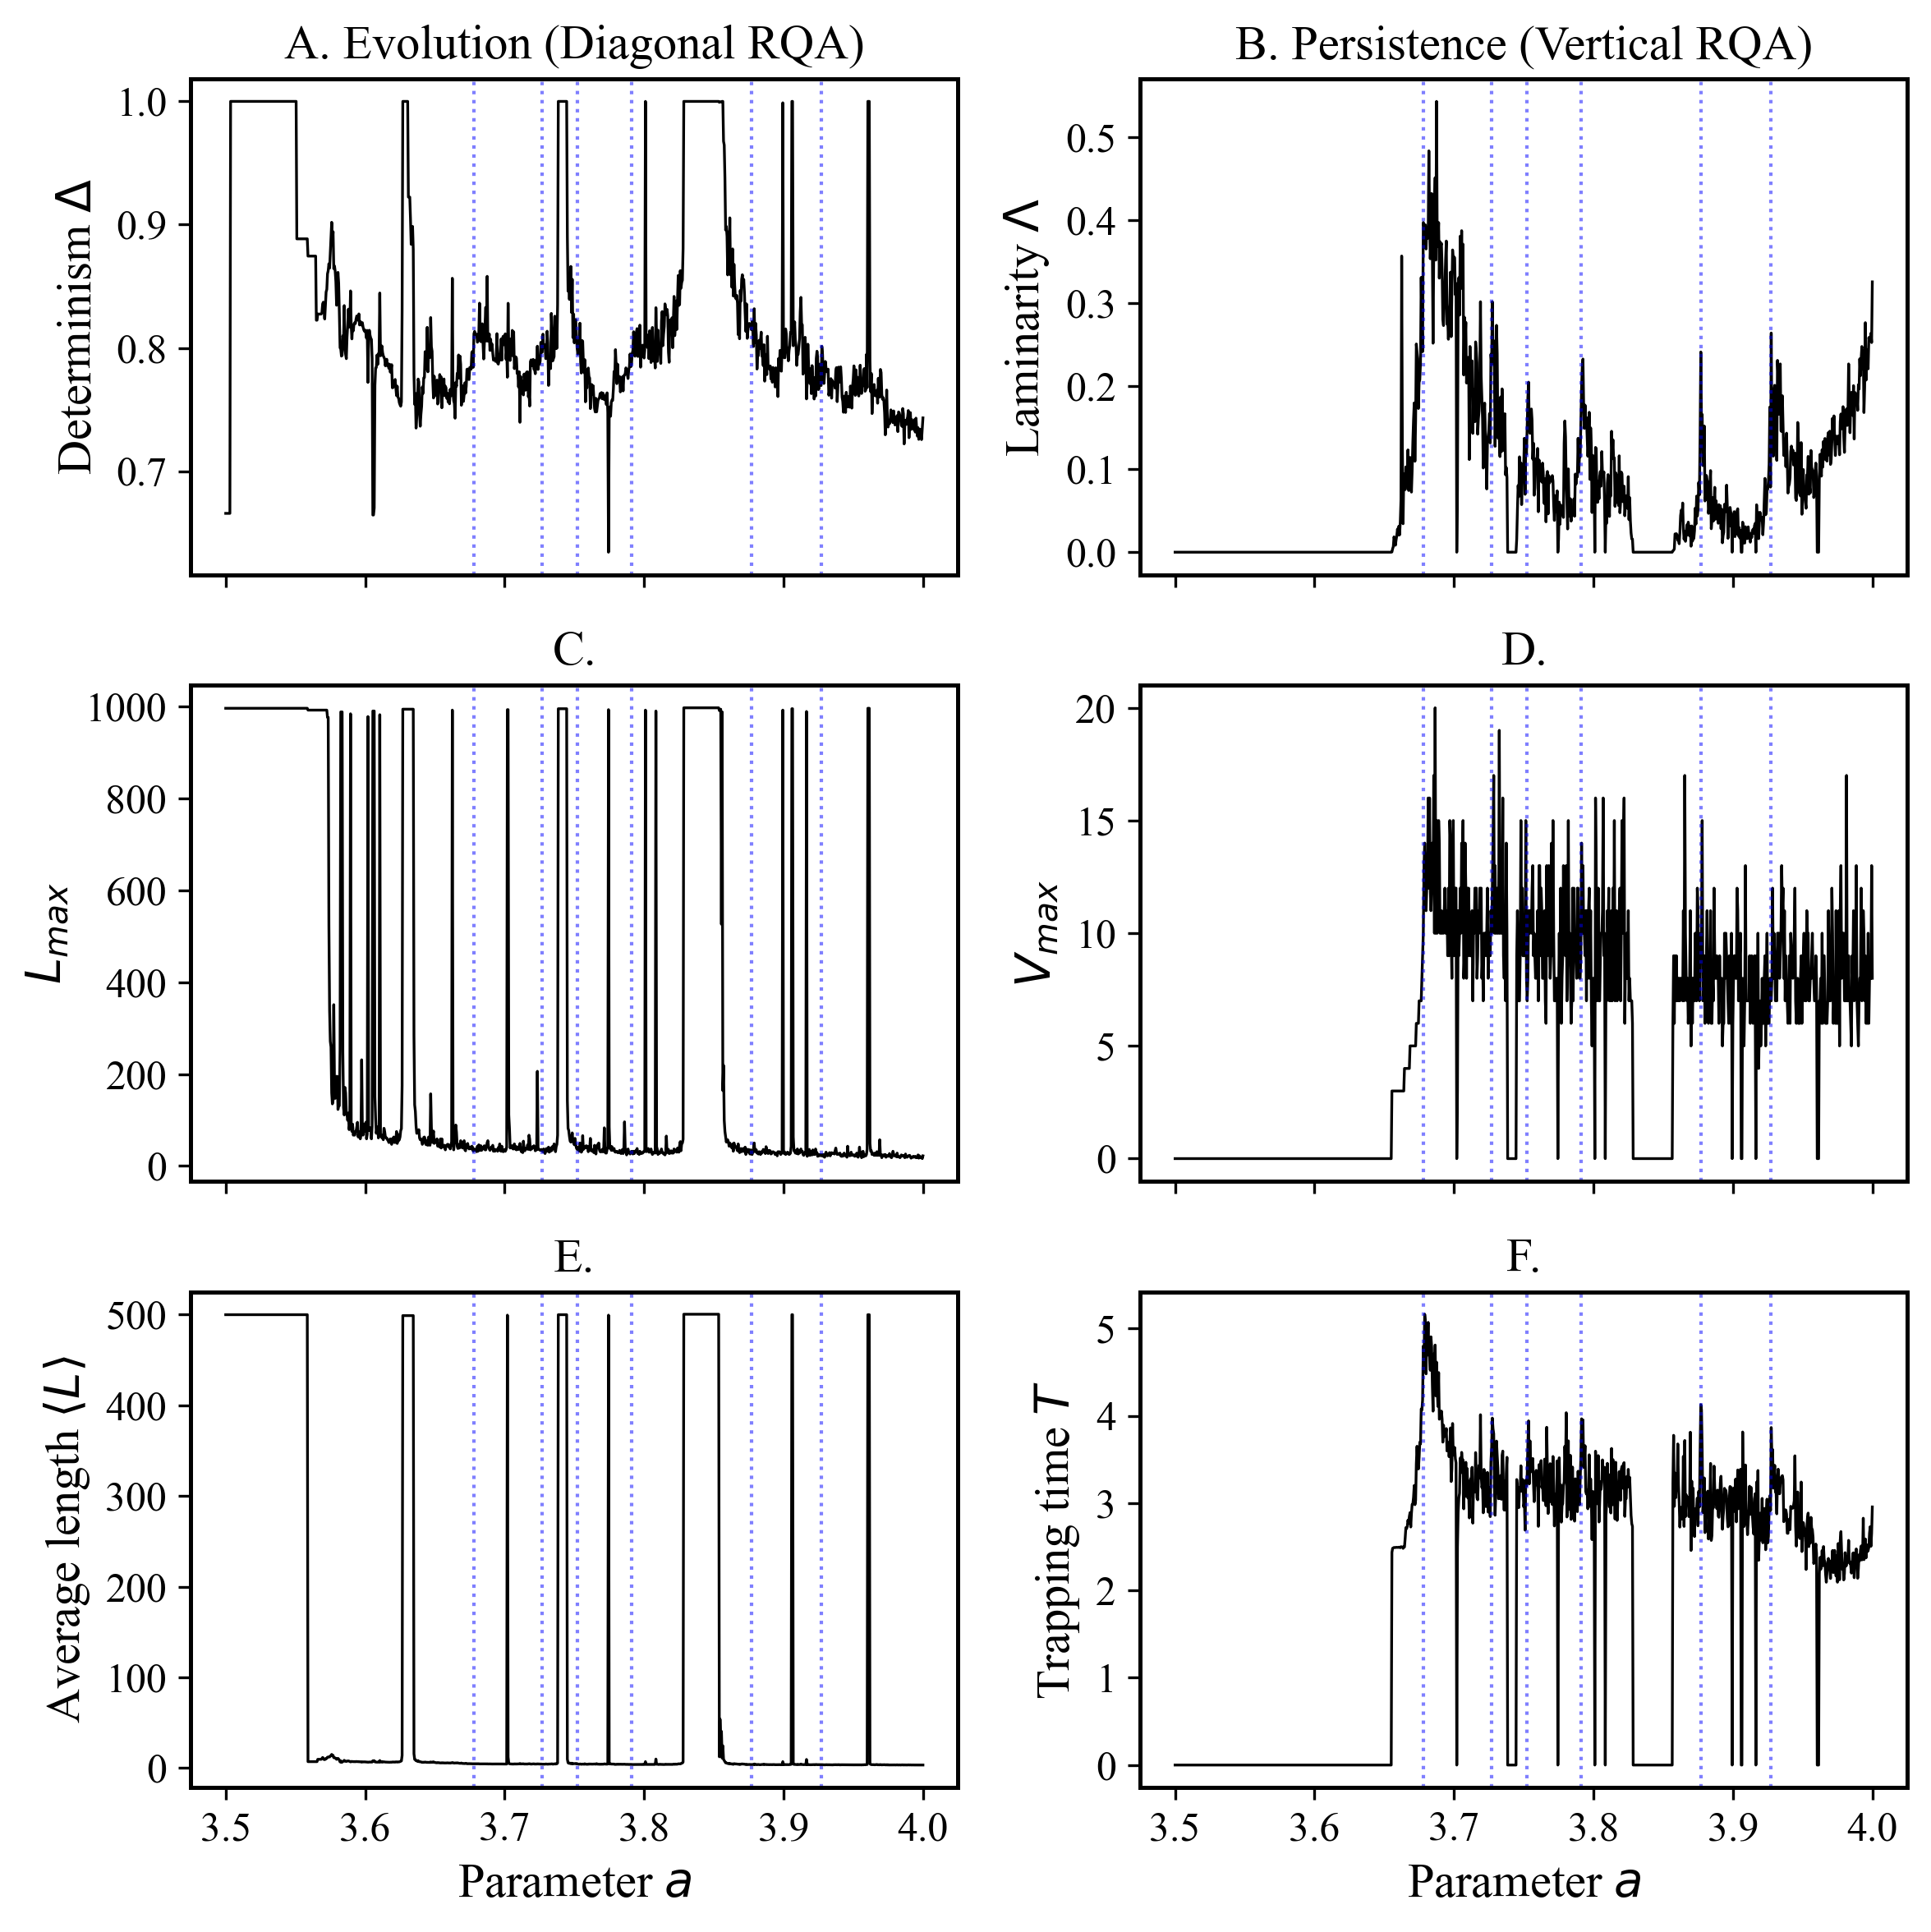

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharex=True)

# Cột 1: Diagonal RQA (Evolution)
axes[0, 0].plot(a_values, det_curve, 'k-', linewidth=0.8)
axes[0, 0].set_ylabel(r"Determinism $\Delta$")
axes[0, 0].set_title("A. Evolution (Diagonal RQA)")

axes[1, 0].plot(a_values, lmax_curve, 'k-', linewidth=0.8)
axes[1, 0].set_ylabel(r"$L_{max}$")
axes[1, 0].set_title("C.")

axes[2, 0].plot(a_values, lmean_curve, 'k-', linewidth=0.8)
axes[2, 0].set_ylabel(r"Average length $\langle L \rangle$")
axes[2, 0].set_xlabel(r"Parameter $a$")
axes[2, 0].set_title("E.")

# Cột 2: Vertical RQA (Persistence)
axes[0, 1].plot(a_values, lam_curve, 'k-', linewidth=0.8)
axes[0, 1].set_ylabel(r"Laminarity $\Lambda$")
axes[0, 1].set_title("B. Persistence (Vertical RQA)")

axes[1, 1].plot(a_values, vmax_curve, 'k-', linewidth=0.8)
axes[1, 1].set_ylabel(r"$V_{max}$")
axes[1, 1].set_title("D.")

axes[2, 1].plot(a_values, tt_curve, 'k-', linewidth=0.8)
axes[2, 1].set_ylabel(r"Trapping time $T$")
axes[2, 1].set_xlabel(r"Parameter $a$")
axes[2, 1].set_title("F.")

# Kẻ 6 đường đứt nét (Ground Truth) để đối chứng sự chuyển pha
# Sử dụng axes.flat để vòng lặp ngắn gọn và thanh lịch hơn
for ax in axes.flat:
    for t in chaos_transitions:
        ax.axvline(x=t, color='blue', linestyle=':', linewidth=1.0, alpha=0.5)

plt.tight_layout()
plt.show()